#  BLOCO 1 — Imports e leitura da base de modelagem

In [1]:
# ============================================================
# BLOCO 1 — Imports e leitura da base de modelagem
# Objetivo:
# - Carregar bibliotecas necessárias para o sistema fuzzy Mamdani
# - Usar a mesma base limpa criada no pipeline da Árvore de Decisão
# - Garantir consistência experimental entre os modelos
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Leitura da base limpa/padronizada
df_fuzzy = pd.read_csv("base_modelagem_aviacao.csv")

print("Dimensão da base fuzzy:", df_fuzzy.shape)
print("\nDistribuição do target:")
print(df_fuzzy["ocorrencia_classificacao"].value_counts(normalize=True).round(3))

C:\Users\FelipePedrosodeLimaB\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Dimensão da base fuzzy: (34939, 52)

Distribuição do target:
ocorrencia_classificacao
ACIDENTE           0.605
INCIDENTE          0.276
INCIDENTE GRAVE    0.119
Name: proportion, dtype: float64


In [2]:

''' usar as 10 features da AD
'''

df_fuzzy.shape

(34939, 52)

# BLOCO 2 — Feature Engineering guiado pela Árvore de Decisão

In [3]:
# ============================================================
# BLOCO 2 — Feature Engineering conservador guiado pela AD
#
# Objetivo:
# - Preparar apenas as variáveis necessárias para o sistema fuzzy híbrido
# - Fuzzyficar somente variáveis metodologicamente defensáveis
# - Preservar variáveis categóricas nominais em seus valores originais
#
# Decisão metodológica:
# - aeronave_nivel_dano: será fuzzyficada, pois possui ordem natural de severidade
# - aeronave_pmd: será fuzzyficada, pois é uma variável numérica contínua
# - fator_area: NÃO será fuzzyficada; será usada apenas como condição lógica original
# - ocorrencia_tipo: NÃO será fuzzyficada; será usada apenas como condição lógica original
# ============================================================

df_fuzzy = df_fuzzy.copy()

# -------------------------------------------------
# 1. DANO — variável ordinal que será fuzzyficada
# -------------------------------------------------

def map_dano_refinado(dano):
    dano = str(dano).upper().strip()
    
    if "DESTRU" in dano:
        return "destruida"
    elif "SUBSTANCIAL" in dano:
        return "substancial"
    elif "LEVE" in dano:
        return "leve"
    elif "NENHUM" in dano:
        return "nenhum"
    else:
        return "nao_informado"

df_fuzzy["dano_refinado"] = df_fuzzy["aeronave_nivel_dano"].apply(map_dano_refinado)


# -------------------------------------------------
# 2. PMD — variável numérica contínua que será fuzzyficada
# -------------------------------------------------

df_fuzzy["pmd_limpo"] = pd.to_numeric(
    df_fuzzy["aeronave_pmd"],
    errors="coerce"
)

# Valores inválidos ou iguais a zero são tratados como ausentes
df_fuzzy.loc[df_fuzzy["pmd_limpo"] <= 0, "pmd_limpo"] = np.nan

# Imputação simples pela mediana da própria variável
df_fuzzy["pmd_limpo"] = df_fuzzy["pmd_limpo"].fillna(
    df_fuzzy["pmd_limpo"].median()
)


# -------------------------------------------------
# 3. Condições categóricas preservadas da AD
# -------------------------------------------------
# Importante:
# Estas colunas NÃO representam fuzzyficação nem score.
# Elas apenas operacionalizam as condições categóricas
# extraídas pela Árvore de Decisão.

def is_fator_area_nao_informado(x):
    x = str(x).upper().strip()
    return "NÃO INFORMADO" in x or "NAO INFORMADO" in x

def is_com_trem_de_pouso(x):
    x = str(x).upper().strip()
    return "COM TREM DE POUSO" in x

df_fuzzy["fator_area_nao_informado_flag"] = (
    df_fuzzy["fator_area"].apply(is_fator_area_nao_informado)
)

df_fuzzy["ocorrencia_trem_pouso_flag"] = (
    df_fuzzy["ocorrencia_tipo"].apply(is_com_trem_de_pouso)
)


# -------------------------------------------------
# 4. Verificações
# -------------------------------------------------

print("\nDistribuição — dano_refinado:")
print(df_fuzzy["dano_refinado"].value_counts(normalize=True).round(3))

print("\nResumo — pmd_limpo:")
print(df_fuzzy["pmd_limpo"].describe())

print("\nDistribuição — fator_area original:")
print(df_fuzzy["fator_area"].value_counts(normalize=True).head(10).round(3))

print("\nFlag — fator_area = NÃO INFORMADO:")
print(df_fuzzy["fator_area_nao_informado_flag"].value_counts(normalize=True).round(3))

print("\nDistribuição — ocorrencia_tipo original:")
print(df_fuzzy["ocorrencia_tipo"].value_counts(normalize=True).head(10).round(3))

print("\nFlag — ocorrencia_tipo = COM TREM DE POUSO:")
print(df_fuzzy["ocorrencia_trem_pouso_flag"].value_counts(normalize=True).round(3))


Distribuição — dano_refinado:
dano_refinado
substancial      0.345
destruida        0.250
nenhum           0.234
leve             0.155
nao_informado    0.016
Name: proportion, dtype: float64

Resumo — pmd_limpo:
count     34939.000000
mean      18474.320859
std       32142.280367
min           1.000000
25%        1497.000000
50%        2404.000000
75%        9752.000000
max      181436.630000
Name: pmd_limpo, dtype: float64

Distribuição — fator_area original:
fator_area
FATOR OPERACIONAL    0.396
NÃO INFORMADO        0.333
FATOR HUMANO         0.236
OUTRO                0.024
FATOR MATERIAL       0.012
Name: proportion, dtype: float64

Flag — fator_area = NÃO INFORMADO:
fator_area_nao_informado_flag
False    0.667
True     0.333
Name: proportion, dtype: float64

Distribuição — ocorrencia_tipo original:
ocorrencia_tipo
PERDA DE CONTROLE NO SOLO                             0.122
FALHA DO MOTOR EM VOO                                 0.121
PERDA DE CONTROLE EM VOO                       

# BLOCO 3 — definição dos conjuntos fuzzy

✅ Conjuntos fuzzy definidos: dano, pmd e risco


C:\Users\FelipePedrosodeLimaB\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


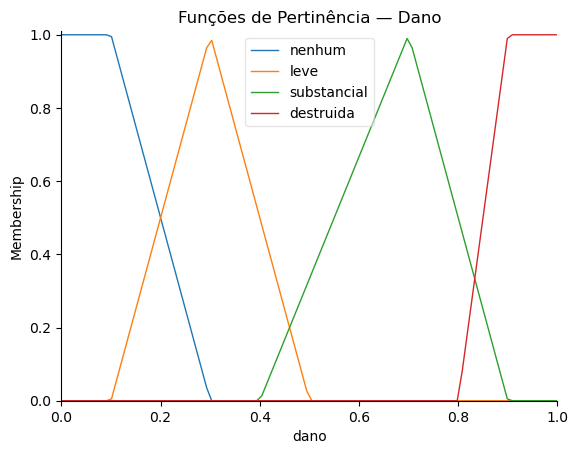

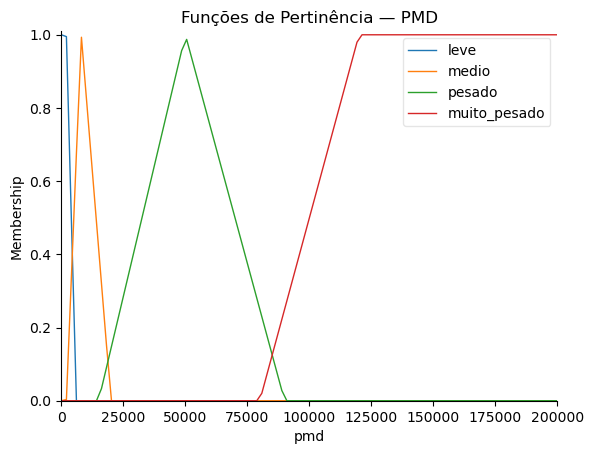

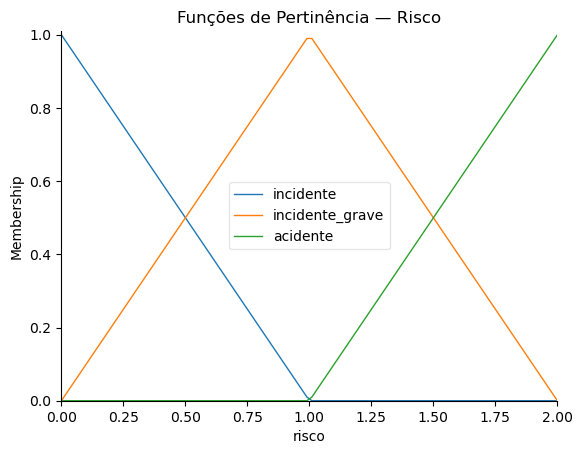

In [4]:
# ============================================================
# BLOCO 3 — Definição dos conjuntos fuzzy
#
# Objetivo:
# - Definir os antecedentes fuzzy do sistema Mamdani
# - Definir a variável fuzzy de saída
# - Manter apenas variáveis metodologicamente defensáveis como fuzzy
#
# Decisão metodológica:
# - dano: fuzzyficado por representar uma variável ordinal de severidade
# - pmd: fuzzyficado por representar uma variável numérica contínua
# - fator_area: NÃO fuzzyficado; usado apenas como condição categórica lógica
# - ocorrencia_tipo: NÃO fuzzyficado; usado apenas como condição categórica lógica
# ============================================================

# -------------------------------
# UNIVERSOS FUZZY
# -------------------------------

dano = ctrl.Antecedent(
    np.linspace(0, 1, 100),
    "dano"
)

pmd = ctrl.Antecedent(
    np.linspace(0, 200000, 100),
    "pmd"
)

risco = ctrl.Consequent(
    np.linspace(0, 2, 100),
    "risco"
)


# -------------------------------
# CONJUNTOS FUZZY — DANO
# -------------------------------
# Variável ordinal:
# nenhum → leve → substancial → destruída

dano["nenhum"] = fuzz.trapmf(
    dano.universe,
    [0.0, 0.0, 0.1, 0.3]
)

dano["leve"] = fuzz.trimf(
    dano.universe,
    [0.1, 0.3, 0.5]
)

dano["substancial"] = fuzz.trimf(
    dano.universe,
    [0.4, 0.7, 0.9]
)

dano["destruida"] = fuzz.trapmf(
    dano.universe,
    [0.8, 0.9, 1.0, 1.0]
)


# -------------------------------
# CONJUNTOS FUZZY — PMD
# -------------------------------
# Variável numérica contínua:
# leve → médio → pesado → muito pesado

pmd["leve"] = fuzz.trapmf(
    pmd.universe,
    [0, 0, 2000, 6000]
)

pmd["medio"] = fuzz.trimf(
    pmd.universe,
    [2000, 8000, 20000]
)

pmd["pesado"] = fuzz.trimf(
    pmd.universe,
    [15000, 50000, 90000]
)

pmd["muito_pesado"] = fuzz.trapmf(
    pmd.universe,
    [80000, 120000, 200000, 200000]
)


# -------------------------------
# CONJUNTOS FUZZY — SAÍDA / RISCO
# -------------------------------
# Saída linguística alinhada às classes oficiais:
# incidente, incidente grave, acidente

risco["incidente"] = fuzz.trimf(
    risco.universe,
    [0, 0, 1]
)

risco["incidente_grave"] = fuzz.trimf(
    risco.universe,
    [0, 1, 2]
)

risco["acidente"] = fuzz.trimf(
    risco.universe,
    [1, 2, 2]
)


print("✅ Conjuntos fuzzy definidos: dano, pmd e risco")


# -------------------------------
# VISUALIZAÇÃO DOS CONJUNTOS
# -------------------------------

dano.view()
plt.title("Funções de Pertinência — Dano")
plt.show()

pmd.view()
plt.title("Funções de Pertinência — PMD")
plt.show()

risco.view()
plt.title("Funções de Pertinência — Risco")
plt.show()

# BLOCO 4 — Regras Fuzzy (guiadas pela Árvore)

In [5]:
# ============================================================
# BLOCO 4 — Regras fuzzy híbridas guiadas pela Árvore de Decisão
#
# Objetivo:
# - Criar regras fuzzy apenas com antecedentes fuzzy defensáveis
# - Preservar fator_area e ocorrencia_tipo como filtros categóricos externos
#
# Importante:
# O scikit-fuzzy não avalia strings diretamente em ctrl.Rule.
# Por isso, as regras são organizadas em grupos.
# Cada grupo será ativado posteriormente de acordo com as condições
# categóricas preservadas da Árvore de Decisão.
#
# Variáveis fuzzy usadas nas regras:
# - dano
# - pmd
#
# Variáveis categóricas usadas como filtros externos:
# - fator_area = "NÃO INFORMADO" ou fator_area != "NÃO INFORMADO"
# - ocorrencia_tipo = "COM TREM DE POUSO" ou != "COM TREM DE POUSO"
# ============================================================


# ============================================================
# GRUPO A — fator_area != "NÃO INFORMADO"
# Regras 1 a 4 da Árvore de Decisão
# ============================================================

# R1
# SE fator_area != "NÃO INFORMADO"
# E dano é substancial OU destruída
# → ACIDENTE
rule1 = ctrl.Rule(
    dano["substancial"] | dano["destruida"],
    risco["acidente"]
)

# R2
# SE fator_area != "NÃO INFORMADO"
# E dano é nenhum
# → INCIDENTE GRAVE
rule2 = ctrl.Rule(
    dano["nenhum"],
    risco["incidente_grave"]
)

# R3
# SE fator_area != "NÃO INFORMADO"
# E dano é leve
# E PMD é leve OU médio OU pesado
# → INCIDENTE GRAVE
rule3 = ctrl.Rule(
    dano["leve"] &
    (pmd["leve"] | pmd["medio"] | pmd["pesado"]),
    risco["incidente_grave"]
)

# R4
# SE fator_area != "NÃO INFORMADO"
# E dano é leve
# E PMD é muito pesado
# → INCIDENTE
rule4 = ctrl.Rule(
    dano["leve"] &
    pmd["muito_pesado"],
    risco["incidente"]
)


# ============================================================
# GRUPO B — fator_area = "NÃO INFORMADO"
# Regras 5 e 6 da Árvore de Decisão
# ============================================================

# R5
# SE fator_area = "NÃO INFORMADO"
# E dano é nenhum OU leve
# → INCIDENTE
rule5 = ctrl.Rule(
    dano["nenhum"] | dano["leve"],
    risco["incidente"]
)

# R6
# SE fator_area = "NÃO INFORMADO"
# E dano é destruída
# → ACIDENTE
rule6 = ctrl.Rule(
    dano["destruida"],
    risco["acidente"]
)


# ============================================================
# GRUPO C — fator_area = "NÃO INFORMADO"
# E ocorrencia_tipo != "COM TREM DE POUSO"
# Regra 7 da Árvore de Decisão
# ============================================================

# R7
# SE fator_area = "NÃO INFORMADO"
# E dano é substancial
# E ocorrencia_tipo != "COM TREM DE POUSO"
# → ACIDENTE
rule7 = ctrl.Rule(
    dano["substancial"],
    risco["acidente"]
)


# ============================================================
# GRUPO D — fator_area = "NÃO INFORMADO"
# E ocorrencia_tipo = "COM TREM DE POUSO"
# Regra 8 da Árvore de Decisão
# ============================================================

# R8
# SE fator_area = "NÃO INFORMADO"
# E dano é substancial
# E ocorrencia_tipo = "COM TREM DE POUSO"
# → INCIDENTE GRAVE
rule8 = ctrl.Rule(
    dano["substancial"],
    risco["incidente_grave"]
)


# ============================================================
# SISTEMAS FUZZY POR GRUPO DE REGRAS
# ============================================================

sistema_fator_informado = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4
])

sistema_fator_nao_informado_base = ctrl.ControlSystem([
    rule5, rule6
])

sistema_fator_nao_informado_sem_trem_pouso = ctrl.ControlSystem([
    rule5, rule6, rule7
])

sistema_fator_nao_informado_com_trem_pouso = ctrl.ControlSystem([
    rule5, rule6, rule8
])

print("✅ Regras fuzzy híbridas definidas com filtros categóricos externos.")

✅ Regras fuzzy híbridas definidas com filtros categóricos externos.


#  BLOCO 5 — Split treino/teste igual ao pipeline da AD

In [6]:
# ============================================================
# BLOCO 5 — Split treino/teste igual ao pipeline da AD
# ============================================================

from sklearn.model_selection import train_test_split

X = df_fuzzy[[
    "aeronave_fatalidades_total",
    "aeronave_assentos",
    "aeronave_nivel_dano",
    "total_recomendacoes",
    "fator_nome",
    "fator_area",
    "aeronave_pmd",
    "aeronave_tipo_operacao",
    "aeronave_tipo_veiculo",
    "ocorrencia_tipo"
]]

y = df_fuzzy["ocorrencia_classificacao"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

df_train = df_fuzzy.loc[X_train.index].copy()
df_test = df_fuzzy.loc[X_test.index].copy()

print("Shape treino:", df_train.shape)
print("Shape teste:", df_test.shape)

print("\nDistribuição target treino:")
print(df_train["ocorrencia_classificacao"].value_counts(normalize=True).round(3))

print("\nDistribuição target teste:")
print(df_test["ocorrencia_classificacao"].value_counts(normalize=True).round(3))

Shape treino: (24457, 56)
Shape teste: (10482, 56)

Distribuição target treino:
ocorrencia_classificacao
ACIDENTE           0.605
INCIDENTE          0.276
INCIDENTE GRAVE    0.119
Name: proportion, dtype: float64

Distribuição target teste:
ocorrencia_classificacao
ACIDENTE           0.605
INCIDENTE          0.276
INCIDENTE GRAVE    0.119
Name: proportion, dtype: float64


# BLOCO 6 — Funções auxiliares para inferência fuzzy híbrida

In [7]:
# ============================================================
# BLOCO 6 — Funções auxiliares para inferência fuzzy híbrida
# ============================================================

from datetime import datetime
import time

# ============================================================
# Conversão categórica → universo fuzzy
#
# O Scikit-Fuzzy recebe entradas numéricas, portanto as
# categorias linguísticas da variável "dano_refinado"
# precisam ser posicionadas dentro do universo fuzzy [0,1].
#
# Os valores abaixo representam os centros aproximados dos
# conjuntos fuzzy definidos anteriormente para a variável dano:
#
# nenhum       ≈ 0.1
# leve         ≈ 0.3
# substancial  ≈ 0.7
# destruida    ≈ 0.95
#
# Dessa forma, NÃO alteramos o significado da categoria
# original. Apenas informamos ao sistema fuzzy qual região
# do universo representa cada termo linguístico.
#
# Exemplo:
# "substancial" → 0.7
# O sistema então calcula automaticamente os graus de
# pertinência utilizando as funções fuzzy definidas.
# ============================================================

map_dano_num = {
    "nenhum": 0.1,
    "leve": 0.3,
    "substancial": 0.7,
    "destruida": 0.95,
    "nao_informado": 0.3
}

def score_para_classe(score):
    if score < 0.5:
        return "INCIDENTE"
    elif score < 1.5:
        return "INCIDENTE GRAVE"
    else:
        return "ACIDENTE"


def selecionar_sistema(row):
    fator_nao_informado = row["fator_area_nao_informado_flag"]
    trem_pouso = row["ocorrencia_trem_pouso_flag"]

    if not fator_nao_informado:
        return ctrl.ControlSystemSimulation(sistema_fator_informado)

    if fator_nao_informado and trem_pouso:
        return ctrl.ControlSystemSimulation(sistema_fator_nao_informado_com_trem_pouso)

    return ctrl.ControlSystemSimulation(sistema_fator_nao_informado_sem_trem_pouso)


def inferencia_fuzzy_hibrida(df_input, nome_base="base"):
    scores = []
    preds = []
    erros = 0

    inicio = datetime.now()
    inicio_perf = time.perf_counter()

    print(f"\nInício inferência fuzzy — {nome_base}:",
          inicio.strftime("%Y-%m-%d %H:%M:%S"))

    for _, row in df_input.iterrows():

        try:
            simulador = selecionar_sistema(row)

            simulador.input["dano"] = map_dano_num.get(
                row["dano_refinado"],
                0.3
            )

            simulador.input["pmd"] = row["pmd_limpo"]

            simulador.compute()

            score = simulador.output["risco"]
            pred = score_para_classe(score)

            scores.append(score)
            preds.append(pred)

        except Exception:
            erros += 1
            scores.append(np.nan)
            preds.append(np.nan)

    fim = datetime.now()
    fim_perf = time.perf_counter()

    tempo_segundos = fim_perf - inicio_perf
    tempo_minutos = tempo_segundos / 60

    print(f"Fim inferência fuzzy — {nome_base}:",
          fim.strftime("%Y-%m-%d %H:%M:%S"))

    print(f"Tempo total — {nome_base}: {tempo_segundos:.2f} segundos")
    print(f"Tempo total — {nome_base}: {tempo_minutos:.2f} minutos")
    print(f"Erros — {nome_base}: {erros}")

    return scores, preds, erros, tempo_segundos, tempo_minutos

# BLOCO 7 — Inferência fuzzy no TREINO e no TESTE

In [8]:
# ============================================================
# BLOCO 7 — Inferência fuzzy no TREINO e no TESTE
# ============================================================

scores_train, preds_train, erros_train, tempo_train_seg, tempo_train_min = (
    inferencia_fuzzy_hibrida(df_train, nome_base="TREINO")
)

df_train["score_fuzzy"] = scores_train
df_train["pred_fuzzy"] = preds_train

print("\nDistribuição predita — TREINO:")
print(df_train["pred_fuzzy"].value_counts(dropna=False))


scores_test, preds_test, erros_test, tempo_test_seg, tempo_test_min = (
    inferencia_fuzzy_hibrida(df_test, nome_base="TESTE")
)

df_test["score_fuzzy"] = scores_test
df_test["pred_fuzzy"] = preds_test

print("\nDistribuição predita — TESTE:")
print(df_test["pred_fuzzy"].value_counts(dropna=False))


Início inferência fuzzy — TREINO: 2026-06-01 10:04:37
Fim inferência fuzzy — TREINO: 2026-06-01 10:05:17
Tempo total — TREINO: 39.68 segundos
Tempo total — TREINO: 0.66 minutos
Erros — TREINO: 8143

Distribuição predita — TREINO:
pred_fuzzy
ACIDENTE           13526
NaN                 8143
INCIDENTE GRAVE     2694
INCIDENTE             94
Name: count, dtype: int64

Início inferência fuzzy — TESTE: 2026-06-01 10:05:17
Fim inferência fuzzy — TESTE: 2026-06-01 10:05:33
Tempo total — TESTE: 15.76 segundos
Tempo total — TESTE: 0.26 minutos
Erros — TESTE: 3478

Distribuição predita — TESTE:
pred_fuzzy
ACIDENTE           5792
NaN                3478
INCIDENTE GRAVE    1163
INCIDENTE            49
Name: count, dtype: int64


# BLOCO 8 — Avaliação do modelo fuzzy no TREINO e no TESTE


Dimensão avaliada — TREINO: (16314, 58)

Classification Report — TREINO:

                 precision    recall  f1-score   support

      INCIDENTE       0.90      0.40      0.56       212
INCIDENTE GRAVE       0.72      0.86      0.78      2252
       ACIDENTE       0.98      0.95      0.97     13850

       accuracy                           0.93     16314
      macro avg       0.87      0.74      0.77     16314
   weighted avg       0.94      0.93      0.94     16314



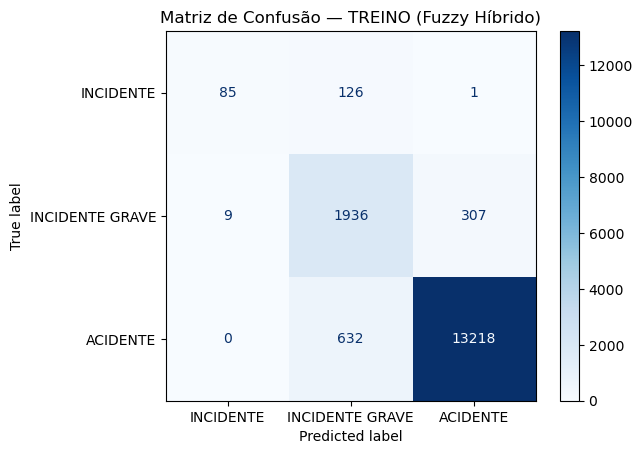


Distribuição REAL — TREINO:
ocorrencia_classificacao
ACIDENTE           0.849
INCIDENTE GRAVE    0.138
INCIDENTE          0.013
Name: proportion, dtype: float64

Distribuição PREDITA — TREINO:
pred_fuzzy
ACIDENTE           0.829
INCIDENTE GRAVE    0.165
INCIDENTE          0.006
Name: proportion, dtype: float64

Score médio por classe predita — TREINO:
pred_fuzzy
ACIDENTE           1.667
INCIDENTE          0.358
INCIDENTE GRAVE    1.000
Name: score_fuzzy, dtype: float64

Dimensão avaliada — TESTE: (7004, 58)

Classification Report — TESTE:

                 precision    recall  f1-score   support

      INCIDENTE       0.88      0.41      0.56       105
INCIDENTE GRAVE       0.72      0.86      0.78       972
       ACIDENTE       0.98      0.95      0.97      5927

       accuracy                           0.93      7004
      macro avg       0.86      0.74      0.77      7004
   weighted avg       0.94      0.93      0.93      7004



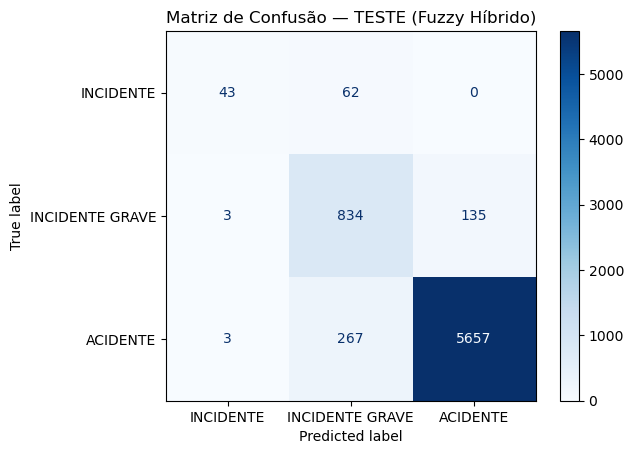


Distribuição REAL — TESTE:
ocorrencia_classificacao
ACIDENTE           0.846
INCIDENTE GRAVE    0.139
INCIDENTE          0.015
Name: proportion, dtype: float64

Distribuição PREDITA — TESTE:
pred_fuzzy
ACIDENTE           0.827
INCIDENTE GRAVE    0.166
INCIDENTE          0.007
Name: proportion, dtype: float64

Score médio por classe predita — TESTE:
pred_fuzzy
ACIDENTE           1.667
INCIDENTE          0.358
INCIDENTE GRAVE    1.000
Name: score_fuzzy, dtype: float64


In [10]:
# ============================================================
# BLOCO 8 — Avaliação do modelo fuzzy no TREINO e no TESTE
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

labels = ["INCIDENTE", "INCIDENTE GRAVE", "ACIDENTE"]

def avaliar_fuzzy(df_base, nome_base="base"):

    df_eval = df_base.dropna(
        subset=["pred_fuzzy", "ocorrencia_classificacao"]
    ).copy()

    print(f"\nDimensão avaliada — {nome_base}:", df_eval.shape)

    print(f"\nClassification Report — {nome_base}:\n")
    print(classification_report(
        df_eval["ocorrencia_classificacao"],
        df_eval["pred_fuzzy"],
        labels=labels
    ))

    cm = confusion_matrix(
        df_eval["ocorrencia_classificacao"],
        df_eval["pred_fuzzy"],
        labels=labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusão — {nome_base} (Fuzzy Híbrido)")
    plt.show()

    print(f"\nDistribuição REAL — {nome_base}:")
    print(df_eval["ocorrencia_classificacao"].value_counts(normalize=True).round(3))

    print(f"\nDistribuição PREDITA — {nome_base}:")
    print(df_eval["pred_fuzzy"].value_counts(normalize=True).round(3))

    print(f"\nScore médio por classe predita — {nome_base}:")
    print(df_eval.groupby("pred_fuzzy")["score_fuzzy"].mean().round(3))

    return df_eval


df_train_eval = avaliar_fuzzy(df_train, nome_base="TREINO")
df_test_eval = avaliar_fuzzy(df_test, nome_base="TESTE")

# BLOCO 8.0 — Instalar biblioteca

In [11]:
#!pip install pygad

In [12]:
import pygad

# ============================================================
# BLOCO 8.1 — Lista de regras para o AG (VERSÃO FINAL)
# ============================================================

# ✅ Apenas as 8 regras reais do modelo

lista_regras = [
    rule1,
    rule2,
    rule3,
    rule4,
    rule5,
    rule6,
    rule7,
    rule8
]

print("✅ Total de regras usadas no GA:", len(lista_regras))


✅ Total de regras usadas no GA: 8


# BLOCO 8.2 — Função de Fitness

In [13]:
# ============================================================
# BLOCO 8.2 — Função de Fitness do AG
# Versão alinhada à metodologia final:
# - Sem fator_area fuzzy
# - Sem ocorrencia_tipo fuzzy
# - Sem fallback
# - Com filtros categóricos preservados
# - Envia PMD somente quando as regras aplicáveis usam PMD
# ============================================================

import numpy as np
from sklearn.metrics import f1_score

CLASSES = ["INCIDENTE", "INCIDENTE GRAVE", "ACIDENTE"]

USAR_SUBSET_TREINO = False

if USAR_SUBSET_TREINO:
    df_avaliacao = df_train.sample(3000, random_state=42)
    print("⚡ Usando subset do treino:", df_avaliacao.shape)
else:
    df_avaliacao = df_train
    print("🧠 Usando treino COMPLETO:", df_avaliacao.shape)


# ============================================================
# Seleção dos NOMES das regras aplicáveis por filtro categórico
# ============================================================

def selecionar_nomes_regras_por_filtro(row):
    """
    Seleciona os nomes das regras aplicáveis a cada registro,
    preservando as condições categóricas originais extraídas da AD.

    Não cria novas regras.
    Apenas organiza as 8 regras originais por filtros categóricos.
    """

    fator_nao_informado = row["fator_area_nao_informado_flag"]
    trem_pouso = row["ocorrencia_trem_pouso_flag"]

    # Regras 1 a 4:
    # fator_area != "NÃO INFORMADO"
    if not fator_nao_informado:
        return ["rule1", "rule2", "rule3", "rule4"]

    # Regras 5, 6 e 8:
    # fator_area = "NÃO INFORMADO"
    # ocorrencia_tipo = "COM TREM DE POUSO"
    if fator_nao_informado and trem_pouso:
        return ["rule5", "rule6", "rule8"]

    # Regras 5, 6 e 7:
    # fator_area = "NÃO INFORMADO"
    # ocorrencia_tipo != "COM TREM DE POUSO"
    return ["rule5", "rule6", "rule7"]


# ============================================================
# Função de avaliação de uma solução do AG
# ============================================================

def avaliar_regras_ag(solution):
    """
    Avalia uma combinação binária das 8 regras candidatas.

    Cada gene representa se uma regra está ativa:
    1 = regra utilizada
    0 = regra removida

    O fitness combina:
    - F1 macro
    - desempenho em INCIDENTE GRAVE
    - cobertura de predição
    - pequena penalização por número de regras
    """

    genes = np.array(solution).round().astype(int)

    nomes_regras = [
        "rule1", "rule2", "rule3", "rule4",
        "rule5", "rule6", "rule7", "rule8"
    ]

    regras_ativas_dict = {
        nome: regra if gene == 1 else None
        for nome, regra, gene in zip(nomes_regras, lista_regras, genes)
    }

    n_regras_ativas = int(genes.sum())

    # Evita soluções excessivamente pobres
    if n_regras_ativas < 3:
        return 0.0

    preds = []
    erros = 0

    for _, row in df_avaliacao.iterrows():

        try:
            # --------------------------------------------------
            # 1. Seleciona os nomes das regras aplicáveis
            #    de acordo com os filtros categóricos originais
            # --------------------------------------------------

            nomes_linha = selecionar_nomes_regras_por_filtro(row)

            # --------------------------------------------------
            # 2. Mantém somente regras ativas pelo cromossomo
            # --------------------------------------------------

            regras_linha = [
                regras_ativas_dict[nome]
                for nome in nomes_linha
                if regras_ativas_dict.get(nome) is not None
            ]

            # Se nenhuma regra aplicável estiver ativa,
            # a solução não cobre este registro.
            if len(regras_linha) == 0:
                preds.append("SEM_PREDICAO")
                erros += 1
                continue

            # --------------------------------------------------
            # 3. Cria sistema fuzzy temporário da linha
            # --------------------------------------------------

            sistema_temp = ctrl.ControlSystem(regras_linha)
            simulador_temp = ctrl.ControlSystemSimulation(sistema_temp)

            # --------------------------------------------------
            # 4. Entrada DANO — sempre usada
            # --------------------------------------------------

            simulador_temp.input["dano"] = map_dano_num.get(
                row["dano_refinado"],
                0.3
            )

            # --------------------------------------------------
            # 5. Entrada PMD — usada somente nas regras 3 e 4
            # --------------------------------------------------
            # Importante:
            # Regras 1, 2, 5, 6, 7 e 8 não usam PMD.
            # Enviar PMD para sistemas que não possuem esse
            # antecedente pode gerar erro no scikit-fuzzy.

            usa_pmd = any(
                nome in ["rule3", "rule4"]
                for nome in nomes_linha
                if regras_ativas_dict.get(nome) is not None
            )

            if usa_pmd:
                simulador_temp.input["pmd"] = row["pmd_limpo"]

            # --------------------------------------------------
            # 6. Inferência fuzzy
            # --------------------------------------------------

            simulador_temp.compute()

            score = simulador_temp.output["risco"]
            pred = score_para_classe(score)

            preds.append(pred)

        except Exception:
            preds.append("SEM_PREDICAO")
            erros += 1

    y_true = df_avaliacao["ocorrencia_classificacao"]

    f1_macro = f1_score(
        y_true,
        preds,
        labels=CLASSES,
        average="macro",
        zero_division=0
    )

    f1_grave = f1_score(
        y_true,
        preds,
        labels=["INCIDENTE GRAVE"],
        average="macro",
        zero_division=0
    )

    cobertura = np.mean(np.array(preds) != "SEM_PREDICAO")

    penalizacao_complexidade = 0.01 * n_regras_ativas

    fitness = (
        f1_macro
        + 0.20 * f1_grave
        + 0.05 * cobertura
        - penalizacao_complexidade
    )

    return max(fitness, 0.0)


# ============================================================
# Teste inicial com todas as 8 regras ativas
# ============================================================

solucao_teste = np.ones(len(lista_regras))
fitness_teste = avaliar_regras_ag(solucao_teste)

print("✅ Fitness inicial com 8 regras:", round(fitness_teste, 4))

🧠 Usando treino COMPLETO: (24457, 58)
✅ Fitness inicial com 8 regras: 0.9676


In [19]:
# ============================================================
# Diagnóstico da solução com todas as regras ativas
# Objetivo:
# - Verificar cobertura
# - Verificar SEM_PREDICAO
# - Verificar Classification Report
# - Validar a função de fitness antes de rodar o AG
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

def diagnosticar_regras_ag(solution):

    genes = np.array(solution).round().astype(int)

    nomes_regras = [
        "rule1", "rule2", "rule3", "rule4",
        "rule5", "rule6", "rule7", "rule8"
    ]

    regras_ativas_dict = {
        nome: regra if gene == 1 else None
        for nome, regra, gene in zip(
            nomes_regras,
            lista_regras,
            genes
        )
    }

    preds = []
    erros = 0

    for _, row in df_avaliacao.iterrows():

        try:

            nomes_linha = selecionar_nomes_regras_por_filtro(row)

            regras_linha = [
                regras_ativas_dict[nome]
                for nome in nomes_linha
                if regras_ativas_dict.get(nome) is not None
            ]

            if len(regras_linha) == 0:

                preds.append("SEM_PREDICAO")
                erros += 1
                continue

            sistema_temp = ctrl.ControlSystem(regras_linha)

            simulador_temp = ctrl.ControlSystemSimulation(
                sistema_temp
            )

            # -------------------------------
            # DANO
            # -------------------------------

            simulador_temp.input["dano"] = map_dano_num.get(
                row["dano_refinado"],
                0.3
            )

            # -------------------------------
            # PMD somente se necessário
            # -------------------------------

            usa_pmd = any(
                nome in ["rule3", "rule4"]
                for nome in nomes_linha
                if regras_ativas_dict.get(nome) is not None
            )

            if usa_pmd:

                simulador_temp.input["pmd"] = row["pmd_limpo"]

            simulador_temp.compute()

            score = simulador_temp.output["risco"]

            pred = score_para_classe(score)

            preds.append(pred)

        except Exception:

            preds.append("SEM_PREDICAO")
            erros += 1

    # ====================================================
    # RESULTADOS
    # ====================================================

    print("\n==============================")
    print("DIAGNÓSTICO DO SISTEMA FUZZY")
    print("==============================")

    print("\nErros / sem predição:")
    print(erros)

    cobertura = np.mean(
        np.array(preds) != "SEM_PREDICAO"
    )

    print("\nCobertura:")
    print(round(cobertura, 4))

    print("\nDistribuição predita:")
    print(
        pd.Series(preds)
        .value_counts(normalize=True)
        .round(3)
    )

    print("\nClassification Report:")

    print(
        classification_report(
            df_avaliacao["ocorrencia_classificacao"],
            preds,
            labels=CLASSES,
            zero_division=0
        )
    )

    return preds


# ============================================================
# TESTE COM TODAS AS 8 REGRAS ATIVAS
# ============================================================

preds_diag = diagnosticar_regras_ag(
    np.ones(len(lista_regras))
)


DIAGNÓSTICO DO SISTEMA FUZZY

Erros / sem predição:
0

Cobertura:
1.0

Distribuição predita:
ACIDENTE           0.583
INCIDENTE          0.295
INCIDENTE GRAVE    0.122
Name: proportion, dtype: float64

Classification Report:
                 precision    recall  f1-score   support

      INCIDENTE       0.91      0.97      0.94      6754
INCIDENTE GRAVE       0.66      0.68      0.67      2914
       ACIDENTE       0.97      0.94      0.96     14789

       accuracy                           0.92     24457
      macro avg       0.85      0.86      0.86     24457
   weighted avg       0.92      0.92      0.92     24457



In [14]:
# ============================================================
# Diagnóstico da solução com 8 regras ativas
# ============================================================

def diagnosticar_regras_ag(solution):
    genes = np.array(solution).round().astype(int)

    nomes_regras = [
        "rule1", "rule2", "rule3", "rule4",
        "rule5", "rule6", "rule7", "rule8"
    ]

    regras_ativas_dict = {
        nome: regra if gene == 1 else None
        for nome, regra, gene in zip(nomes_regras, lista_regras, genes)
    }

    preds = []
    erros = 0

    for _, row in df_avaliacao.iterrows():
        try:
            regras_linha = selecionar_regras_por_filtro(row, regras_ativas_dict)
            regras_linha = [r for r in regras_linha if r is not None]

            if len(regras_linha) == 0:
                preds.append("SEM_PREDICAO")
                erros += 1
                continue

            sistema_temp = ctrl.ControlSystem(regras_linha)
            simulador_temp = ctrl.ControlSystemSimulation(sistema_temp)

            simulador_temp.input["dano"] = map_dano_num.get(row["dano_refinado"], 0.3)
            simulador_temp.input["pmd"] = row["pmd_limpo"]

            simulador_temp.compute()

            score = simulador_temp.output["risco"]
            preds.append(score_para_classe(score))

        except Exception:
            preds.append("SEM_PREDICAO")
            erros += 1

    print("Erros / sem predição:", erros)
    print("Cobertura:", round(np.mean(np.array(preds) != "SEM_PREDICAO"), 4))

    print("\nDistribuição predita:")
    print(pd.Series(preds).value_counts(normalize=True).round(3))

    print("\nClassification Report:")
    print(classification_report(
        df_avaliacao["ocorrencia_classificacao"],
        preds,
        labels=CLASSES,
        zero_division=0
    ))

    return preds

preds_diag = diagnosticar_regras_ag(np.ones(len(lista_regras)))

Erros / sem predição: 8143
Cobertura: 0.667

Distribuição predita:
ACIDENTE           0.553
SEM_PREDICAO       0.333
INCIDENTE GRAVE    0.110
INCIDENTE          0.004
Name: proportion, dtype: float64

Classification Report:
                 precision    recall  f1-score   support

      INCIDENTE       0.90      0.01      0.02      6754
INCIDENTE GRAVE       0.72      0.66      0.69      2914
       ACIDENTE       0.98      0.89      0.93     14789

      micro avg       0.93      0.62      0.75     24457
      macro avg       0.87      0.52      0.55     24457
   weighted avg       0.93      0.62      0.65     24457



In [15]:
print(df_avaliacao["dano_refinado"].value_counts())

dano_refinado
substancial      8483
destruida        6066
nenhum           5710
leve             3784
nao_informado     414
Name: count, dtype: int64


In [16]:
print(
    df_avaliacao[
        df_avaliacao["pred_fuzzy"].isna()
    ]["dano_refinado"].value_counts()
)

dano_refinado
nenhum           4573
leve             2284
substancial       862
nao_informado     263
destruida         161
Name: count, dtype: int64


In [14]:
# ============================================================
# BLOCO 8.3 — AG com monitoramento de convergência + tempo
# ============================================================

import pygad
from datetime import datetime


def formatar_tempo(delta):
    total_segundos = int(delta.total_seconds())
    horas = total_segundos // 3600
    minutos = (total_segundos % 3600) // 60
    segundos = total_segundos % 60
    return f"{horas}h {minutos}m {segundos}s"


melhor_fitness_global = [0]
geracao_melhor = [0]
contador_estagnado = [0]

LIMITE_ESTAGNACAO = 3


def on_generation_monitoramento(ga):

    fitness_atual = ga.best_solution()[1]
    geracao = ga.generations_completed

    if fitness_atual > melhor_fitness_global[0]:

        melhor_fitness_global[0] = fitness_atual
        geracao_melhor[0] = geracao
        contador_estagnado[0] = 0

        print(
            f"✅ Nova melhoria -> Geração {geracao} | "
            f"Fitness: {fitness_atual:.4f}"
        )

    else:

        contador_estagnado[0] += 1

        print(
            f"Geração {geracao} | Fitness: {fitness_atual:.4f} | "
            f"Sem melhora ({contador_estagnado[0]})"
        )

    if contador_estagnado[0] >= LIMITE_ESTAGNACAO:

        print("\n⛔ Early Stopping ativado!")
        print(f"➡ Melhor fitness: {melhor_fitness_global[0]:.4f}")
        print(f"➡ Convergência na geração: {geracao_melhor[0]}")

        return "stop"


def fitness_function(ga_instance, solution, solution_idx):
    return avaliar_regras_ag(solution)


inicio_ag = datetime.now()

print(f"🚀 Início do AG: {inicio_ag.strftime('%d/%m/%Y %H:%M:%S')}")


ga_instance = pygad.GA(

    num_generations=10,
    num_parents_mating=6,

    fitness_func=fitness_function,

    sol_per_pop=30,
    num_genes=len(lista_regras),

    gene_type=int,
    gene_space=[0, 1],

    parent_selection_type="sss",
    keep_parents=3,

    crossover_type="single_point",

    mutation_type="random",
    mutation_percent_genes=20,

    on_generation=on_generation_monitoramento,

    random_seed=42
)


print("\n🚀 Iniciando AG...\n")

ga_instance.run()

print("\n✅ AG finalizado!")


fim_ag = datetime.now()

tempo_total_ag = fim_ag - inicio_ag

print(f"\n✅ Fim do AG: {fim_ag.strftime('%d/%m/%Y %H:%M:%S')}")

print("\n⏱️ Tempo total de execução:")
print(formatar_tempo(tempo_total_ag))
print(f"Tempo total em segundos: {tempo_total_ag.total_seconds():.2f}s")


best_solution, best_fitness, solution_idx = ga_instance.best_solution()

best_solution_binaria = np.round(best_solution).astype(int)

print("\n📊 Resumo da otimização:")
print(f"Melhor fitness encontrado: {best_fitness:.4f}")
print(f"Geração de convergência: {geracao_melhor[0]}")

print("\n🏆 Melhor solução:")
print("Vetor:", best_solution_binaria)
print("Número de regras ativas:", best_solution_binaria.sum())

for i, gene in enumerate(best_solution_binaria, start=1):
    status = "ATIVA" if gene == 1 else "REMOVIDA"
    print(f"Regra {i}: {status}")

🚀 Início do AG: 01/06/2026 10:14:19

🚀 Iniciando AG...

✅ Nova melhoria -> Geração 1 | Fitness: 0.9826
Geração 2 | Fitness: 0.9826 | Sem melhora (1)
Geração 3 | Fitness: 0.9826 | Sem melhora (2)
Geração 4 | Fitness: 0.9826 | Sem melhora (3)

⛔ Early Stopping ativado!
➡ Melhor fitness: 0.9826
➡ Convergência na geração: 1

✅ AG finalizado!

✅ Fim do AG: 01/06/2026 15:55:32

⏱️ Tempo total de execução:
5h 41m 12s
Tempo total em segundos: 20472.95s

📊 Resumo da otimização:
Melhor fitness encontrado: 0.9826
Geração de convergência: 1

🏆 Melhor solução:
Vetor: [1 1 1 0 1 0 1 0]
Número de regras ativas: 5
Regra 1: ATIVA
Regra 2: ATIVA
Regra 3: ATIVA
Regra 4: REMOVIDA
Regra 5: ATIVA
Regra 6: REMOVIDA
Regra 7: ATIVA
Regra 8: REMOVIDA


In [15]:
# ============================================================
# BLOCO 8.4 — Salvar resultado do AG
#
# Objetivo:
# - Evitar rodar novamente 9 horas
# - Permitir reproduzir tabelas e gráficos do artigo
# - Preservar a melhor solução encontrada
# ============================================================

import pickle

resultado_ag = {
    "best_solution": best_solution,
    "best_solution_binaria": best_solution_binaria,
    "best_fitness": best_fitness,
    "geracao_melhor": geracao_melhor[0],
    "tempo_execucao_segundos": tempo_total_ag.total_seconds()
}

with open("resultado_ag.pkl", "wb") as f:
    pickle.dump(resultado_ag, f)

print("✅ Resultado do AG salvo com sucesso!")

✅ Resultado do AG salvo com sucesso!


In [ ]:
# ============================================================
# BLOCO 8.5 — Carregar resultado do AG
# ============================================================

import pickle

with open("resultado_ag.pkl", "rb") as f:
    resultado_ag = pickle.load(f)

best_solution = resultado_ag["best_solution"]
best_solution_binaria = resultado_ag["best_solution_binaria"]
best_fitness = resultado_ag["best_fitness"]

print("✅ Resultado carregado!")

print("\nMelhor fitness:")
print(best_fitness)

print("\nMelhor solução:")
print(best_solution_binaria)

In [16]:
# ============================================================
# BLOCO 9 — Seleção das regras finais do AG
# ============================================================

best_solution_binaria = np.round(best_solution).astype(int)

nomes_regras = [
    "rule1", "rule2", "rule3", "rule4",
    "rule5", "rule6", "rule7", "rule8"
]

regras_finais_dict = {
    nome: regra if gene == 1 else None
    for nome, regra, gene in zip(nomes_regras, lista_regras, best_solution_binaria)
}

regras_finais = [
    regra for regra, gene in zip(lista_regras, best_solution_binaria)
    if gene == 1
]

print("✅ Número de regras finais:", len(regras_finais))
print("Vetor final:", best_solution_binaria)

for i, gene in enumerate(best_solution_binaria, start=1):
    status = "ATIVA" if gene == 1 else "REMOVIDA"
    print(f"Regra {i}: {status}")

✅ Número de regras finais: 5
Vetor final: [1 1 1 0 1 0 1 0]
Regra 1: ATIVA
Regra 2: ATIVA
Regra 3: ATIVA
Regra 4: REMOVIDA
Regra 5: ATIVA
Regra 6: REMOVIDA
Regra 7: ATIVA
Regra 8: REMOVIDA


In [17]:
# ============================================================
# BLOCO 10 — Inferência final GFS no TREINO e TESTE + tempo
# ============================================================

from datetime import datetime
import time

def inferencia_gfs_final(df_input, nome_base="base"):

    scores = []
    preds = []
    erros = 0

    inicio = datetime.now()
    inicio_perf = time.perf_counter()

    print(f"\n🚀 Início inferência GFS — {nome_base}:",
          inicio.strftime("%Y-%m-%d %H:%M:%S"))

    for _, row in df_input.iterrows():

        try:
            nomes_linha = selecionar_nomes_regras_por_filtro(row)

            regras_linha = [
                regras_finais_dict[nome]
                for nome in nomes_linha
                if regras_finais_dict.get(nome) is not None
            ]

            if len(regras_linha) == 0:
                scores.append(np.nan)
                preds.append(np.nan)
                erros += 1
                continue

            sistema_temp = ctrl.ControlSystem(regras_linha)
            simulador_temp = ctrl.ControlSystemSimulation(sistema_temp)

            simulador_temp.input["dano"] = map_dano_num.get(
                row["dano_refinado"],
                0.3
            )

            usa_pmd = any(
                nome in ["rule3", "rule4"]
                for nome in nomes_linha
                if regras_finais_dict.get(nome) is not None
            )

            if usa_pmd:
                simulador_temp.input["pmd"] = row["pmd_limpo"]

            simulador_temp.compute()

            score = simulador_temp.output["risco"]
            pred = score_para_classe(score)

            scores.append(score)
            preds.append(pred)

        except Exception:
            scores.append(np.nan)
            preds.append(np.nan)
            erros += 1

    fim = datetime.now()
    fim_perf = time.perf_counter()

    tempo_segundos = fim_perf - inicio_perf
    tempo_minutos = tempo_segundos / 60

    print(f"✅ Fim inferência GFS — {nome_base}:",
          fim.strftime("%Y-%m-%d %H:%M:%S"))

    print(f"⏱️ Tempo total — {nome_base}: {tempo_segundos:.2f} segundos")
    print(f"⏱️ Tempo total — {nome_base}: {tempo_minutos:.2f} minutos")
    print(f"Erros / sem predição — {nome_base}: {erros}")

    return scores, preds, erros, tempo_segundos, tempo_minutos


scores_gfs_train, preds_gfs_train, erros_gfs_train, tempo_gfs_train_seg, tempo_gfs_train_min = (
    inferencia_gfs_final(df_train, nome_base="TREINO")
)

df_train["score_gfs"] = scores_gfs_train
df_train["pred_gfs"] = preds_gfs_train


scores_gfs_test, preds_gfs_test, erros_gfs_test, tempo_gfs_test_seg, tempo_gfs_test_min = (
    inferencia_gfs_final(df_test, nome_base="TESTE")
)

df_test["score_gfs"] = scores_gfs_test
df_test["pred_gfs"] = preds_gfs_test


🚀 Início inferência GFS — TREINO: 2026-06-01 21:23:03
✅ Fim inferência GFS — TREINO: 2026-06-01 21:26:48
⏱️ Tempo total — TREINO: 225.01 segundos
⏱️ Tempo total — TREINO: 3.75 minutos
Erros / sem predição — TREINO: 76

🚀 Início inferência GFS — TESTE: 2026-06-01 21:26:48
✅ Fim inferência GFS — TESTE: 2026-06-01 21:28:19
⏱️ Tempo total — TESTE: 90.98 segundos
⏱️ Tempo total — TESTE: 1.52 minutos
Erros / sem predição — TESTE: 36



📊 Dimensão avaliada — TREINO: (24381, 60)

📊 Classification Report — GFS TREINO:

                 precision    recall  f1-score   support

      INCIDENTE       0.89      0.59      0.71      6752
INCIDENTE GRAVE       0.36      0.72      0.48      2908
       ACIDENTE       0.97      0.93      0.95     14721

       accuracy                           0.81     24381
      macro avg       0.74      0.75      0.71     24381
   weighted avg       0.88      0.81      0.83     24381



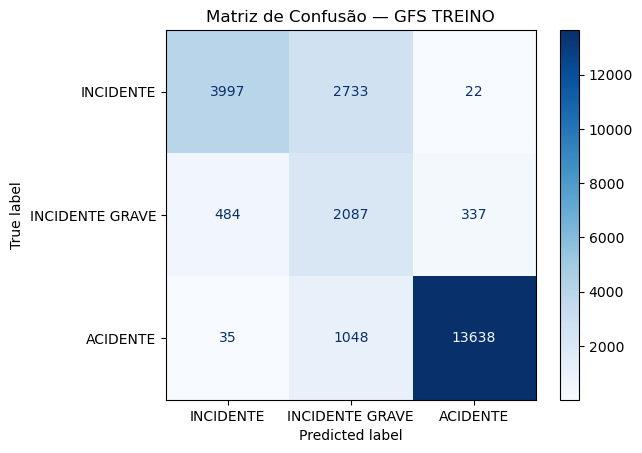


Distribuição REAL — TREINO:
ocorrencia_classificacao
ACIDENTE           0.604
INCIDENTE          0.277
INCIDENTE GRAVE    0.119
Name: proportion, dtype: float64

Distribuição PREDITA — GFS TREINO:
pred_gfs
ACIDENTE           0.574
INCIDENTE GRAVE    0.241
INCIDENTE          0.185
Name: proportion, dtype: float64

Score médio por classe predita — GFS TREINO:
pred_gfs
ACIDENTE           1.667
INCIDENTE          0.342
INCIDENTE GRAVE    0.938
Name: score_gfs, dtype: float64

📊 Dimensão avaliada — TESTE: (10446, 60)

📊 Classification Report — GFS TESTE:

                 precision    recall  f1-score   support

      INCIDENTE       0.87      0.57      0.69      2892
INCIDENTE GRAVE       0.35      0.72      0.47      1246
       ACIDENTE       0.97      0.92      0.95      6308

       accuracy                           0.80     10446
      macro avg       0.73      0.74      0.70     10446
   weighted avg       0.87      0.80      0.82     10446



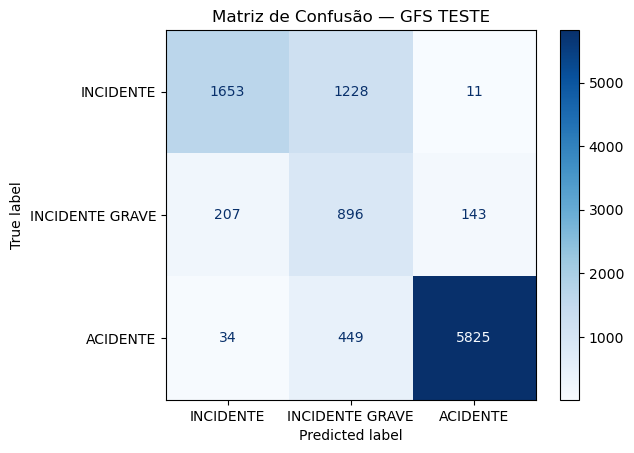


Distribuição REAL — TESTE:
ocorrencia_classificacao
ACIDENTE           0.604
INCIDENTE          0.277
INCIDENTE GRAVE    0.119
Name: proportion, dtype: float64

Distribuição PREDITA — GFS TESTE:
pred_gfs
ACIDENTE           0.572
INCIDENTE GRAVE    0.246
INCIDENTE          0.181
Name: proportion, dtype: float64

Score médio por classe predita — GFS TESTE:
pred_gfs
ACIDENTE           1.667
INCIDENTE          0.342
INCIDENTE GRAVE    0.936
Name: score_gfs, dtype: float64


In [18]:
# ============================================================
# BLOCO 11 — Avaliação final GFS no TREINO e TESTE
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

labels = ["INCIDENTE", "INCIDENTE GRAVE", "ACIDENTE"]

def avaliar_gfs(df_base, nome_base="base"):

    df_eval = df_base.dropna(
        subset=["pred_gfs", "ocorrencia_classificacao"]
    ).copy()

    print(f"\n📊 Dimensão avaliada — {nome_base}:", df_eval.shape)

    print(f"\n📊 Classification Report — GFS {nome_base}:\n")
    print(classification_report(
        df_eval["ocorrencia_classificacao"],
        df_eval["pred_gfs"],
        labels=labels,
        zero_division=0
    ))

    cm = confusion_matrix(
        df_eval["ocorrencia_classificacao"],
        df_eval["pred_gfs"],
        labels=labels
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusão — GFS {nome_base}")
    plt.show()

    print(f"\nDistribuição REAL — {nome_base}:")
    print(df_eval["ocorrencia_classificacao"].value_counts(normalize=True).round(3))

    print(f"\nDistribuição PREDITA — GFS {nome_base}:")
    print(df_eval["pred_gfs"].value_counts(normalize=True).round(3))

    print(f"\nScore médio por classe predita — GFS {nome_base}:")
    print(df_eval.groupby("pred_gfs")["score_gfs"].mean().round(3))

    return df_eval


df_train_gfs_eval = avaliar_gfs(df_train, nome_base="TREINO")
df_test_gfs_eval = avaliar_gfs(df_test, nome_base="TESTE")

In [19]:
# ============================================================
# EXPERIMENTO — Reativação incremental das regras removidas pelo AG
# Objetivo:
# - Avaliar o trade-off entre número de regras e desempenho
# - Verificar se R4, R6 ou R8 são críticas para recuperar performance
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

experimentos_regras = {
    "GFS_5_regras_AG":       np.array([1, 1, 1, 0, 1, 0, 1, 0]),
    "GFS_6_regras_R4":       np.array([1, 1, 1, 1, 1, 0, 1, 0]),
    "GFS_6_regras_R6":       np.array([1, 1, 1, 0, 1, 1, 1, 0]),
    "GFS_6_regras_R8":       np.array([1, 1, 1, 0, 1, 0, 1, 1]),
    "GFS_7_regras_R4_R6":    np.array([1, 1, 1, 1, 1, 1, 1, 0]),
    "GFS_7_regras_R4_R8":    np.array([1, 1, 1, 1, 1, 0, 1, 1]),
    "GFS_7_regras_R6_R8":    np.array([1, 1, 1, 0, 1, 1, 1, 1]),
    "Fuzzy_8_regras":        np.array([1, 1, 1, 1, 1, 1, 1, 1])
}

def avaliar_vetor_regras(vetor, df_base):
    
    nomes_regras = [
        "rule1", "rule2", "rule3", "rule4",
        "rule5", "rule6", "rule7", "rule8"
    ]

    regras_dict = {
        nome: regra if gene == 1 else None
        for nome, regra, gene in zip(nomes_regras, lista_regras, vetor)
    }

    preds = []
    erros = 0

    for _, row in df_base.iterrows():

        try:
            nomes_linha = selecionar_nomes_regras_por_filtro(row)

            regras_linha = [
                regras_dict[nome]
                for nome in nomes_linha
                if regras_dict.get(nome) is not None
            ]

            if len(regras_linha) == 0:
                preds.append(np.nan)
                erros += 1
                continue

            sistema_temp = ctrl.ControlSystem(regras_linha)
            simulador_temp = ctrl.ControlSystemSimulation(sistema_temp)

            simulador_temp.input["dano"] = map_dano_num.get(
                row["dano_refinado"],
                0.3
            )

            usa_pmd = any(
                nome in ["rule3", "rule4"]
                for nome in nomes_linha
                if regras_dict.get(nome) is not None
            )

            if usa_pmd:
                simulador_temp.input["pmd"] = row["pmd_limpo"]

            simulador_temp.compute()

            score = simulador_temp.output["risco"]
            pred = score_para_classe(score)

            preds.append(pred)

        except Exception:
            preds.append(np.nan)
            erros += 1

    return preds, erros


resultados_exp = []

for nome_exp, vetor in experimentos_regras.items():

    print(f"\nRodando experimento: {nome_exp}")

    preds, erros = avaliar_vetor_regras(vetor, df_test)

    df_temp = df_test.copy()
    df_temp["pred_exp"] = preds

    df_eval = df_temp.dropna(subset=["pred_exp", "ocorrencia_classificacao"])

    acc = accuracy_score(
        df_eval["ocorrencia_classificacao"],
        df_eval["pred_exp"]
    )

    macro_f1 = f1_score(
        df_eval["ocorrencia_classificacao"],
        df_eval["pred_exp"],
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        df_eval["ocorrencia_classificacao"],
        df_eval["pred_exp"],
        average="weighted",
        zero_division=0
    )

    cobertura = len(df_eval) / len(df_test)

    resultados_exp.append({
        "experimento": nome_exp,
        "n_regras": int(vetor.sum()),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "cobertura": cobertura,
        "erros_sem_predicao": erros
    })

df_resultados_exp = pd.DataFrame(resultados_exp)

df_resultados_exp = df_resultados_exp.sort_values(
    by=["macro_f1", "accuracy"],
    ascending=False
)

print("\n✅ Resultados dos experimentos:")
display(df_resultados_exp)


Rodando experimento: GFS_5_regras_AG

Rodando experimento: GFS_6_regras_R4

Rodando experimento: GFS_6_regras_R6

Rodando experimento: GFS_6_regras_R8

Rodando experimento: GFS_7_regras_R4_R6

Rodando experimento: GFS_7_regras_R4_R8

Rodando experimento: GFS_7_regras_R6_R8

Rodando experimento: Fuzzy_8_regras

✅ Resultados dos experimentos:


,experimento,n_regras,accuracy,macro_f1,weighted_f1,cobertura,erros_sem_predicao
5,GFS_7_regras_R4_R8,7,0.820287,0.727422,0.836717,0.996947,32
0,GFS_5_regras_AG,5,0.809232,0.712677,0.826780,0.996184,40
1,GFS_6_regras_R4,6,0.809073,0.712035,0.826435,0.996852,33
4,GFS_7_regras_R4_R6,7,0.804010,0.706016,0.822437,0.999332,7
7,Fuzzy_8_regras,8,0.802805,0.704484,0.821195,1.000000,0
3,GFS_6_regras_R8,6,0.800421,0.701549,0.818743,0.997138,30
2,GFS_6_regras_R6,6,0.797804,0.696565,0.816186,0.999332,7
6,GFS_7_regras_R6_R8,7,0.792883,0.691633,0.811921,1.000000,0


In [20]:
melhor_exp = df_resultados_exp.iloc[0]["experimento"]
melhor_vetor = experimentos_regras[melhor_exp]

print("Melhor experimento:", melhor_exp)
print("Vetor:", melhor_vetor)
print("Número de regras:", melhor_vetor.sum())

preds_melhor, erros_melhor = avaliar_vetor_regras(melhor_vetor, df_test)

df_test_exp = df_test.copy()
df_test_exp["pred_exp"] = preds_melhor

df_test_exp_eval = df_test_exp.dropna(subset=["pred_exp"])

print("\nClassification Report — Melhor Experimento:\n")
print(classification_report(
    df_test_exp_eval["ocorrencia_classificacao"],
    df_test_exp_eval["pred_exp"],
    zero_division=0
))

Melhor experimento: GFS_7_regras_R4_R8
Vetor: [1 1 1 1 1 0 1 1]
Número de regras: 7

Classification Report — Melhor Experimento:

                 precision    recall  f1-score   support

       ACIDENTE       0.97      0.92      0.95      6309
      INCIDENTE       0.88      0.58      0.70      2894
INCIDENTE GRAVE       0.35      0.72      0.47      1249

       accuracy                           0.80     10452
      macro avg       0.73      0.74      0.71     10452
   weighted avg       0.87      0.80      0.82     10452

